# Practice Lab Assignment 1 – Neural Network Implementation from Scratch

**Course:** Generative AI Lab

**Department:** CSE (AIML) | **Class:** T.Y. Tech

**Student Name:** *Vineet Kaldate*

**PRN Number:** *202401110074*

**Batch:** *A3*

**Date of Submission:** *15/08/26*

---


## Objective

Implement a simple **feedforward neural network from scratch** in Python, without using any in-built deep learning
libraries (no TensorFlow, PyTorch, or Keras). The implementation covers:

- The **forward pass** (computing weighted sums and applying activation functions)
- **Backpropagation** (computing gradients of the loss with respect to the weights)
- **Training via gradient descent**

Only `numpy` is used for the mathematics of the network itself. `scikit-learn` is used only to (a) load the
benchmark dataset and (b) train a single alternative model for comparison purposes in the analysis section —
it is **not** used to build or train the from-scratch network.


## Part A: Problem Definition

**Dataset:** [Wine recognition dataset](https://archive.ics.uci.edu/ml/datasets/wine) — a classic
multi-class dataset consisting of 178 samples of wine, each derived from a chemical analysis of wines
grown in the same region of Italy but from **3 different cultivars (grape varieties)**. Each sample is
described by **13 numeric features**, including:

1. Alcohol
2. Malic acid
3. Ash
4. Alcalinity of ash
5. Magnesium
6. Total phenols
7. Flavanoids
8. Nonflavanoid phenols
9. Proanthocyanins
10. Color intensity
11. Hue
12. OD280/OD315 of diluted wines
13. Proline

Each sample belongs to one of **3 classes** (cultivars): `class_0`, `class_1`, `class_2`.

**Task:** This is a **multi-class classification** problem — given the 13 chemical-analysis features,
predict which of the 3 cultivars the wine sample came from.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn is used ONLY for loading the dataset, splitting it, and scaling it.
# It is NOT used to build or train the neural network -- that is implemented from scratch below.
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)  # for reproducibility


In [2]:
# Load the Wine dataset
wine = load_wine()
X = wine.data                  # shape: (178, 13)
y = wine.target                 # shape: (178,) -- values in {0, 1, 2}
class_names = wine.target_names

df = pd.DataFrame(X, columns=wine.feature_names)
df['cultivar'] = [class_names[i] for i in y]
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
# Basic dataset overview
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", list(class_names))
print("\nClass distribution:")
print(df['cultivar'].value_counts())


Number of samples: 178
Number of features: 13
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
# Train/test split (80/20), stratified so class proportions are preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (standardization) -- helps gradient descent converge faster
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode the labels for training with cross-entropy loss
def one_hot(y, num_classes):
    encoded = np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded

num_classes = len(class_names)
y_train_oh = one_hot(y_train, num_classes)
y_test_oh = one_hot(y_test, num_classes)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 142
Testing samples: 36


## Part B: Methodology

### Neural Network Architecture
A single-hidden-layer feedforward neural network is used:

| Layer | Neurons | Activation |
|---|---|---|
| Input layer | 4 (one per feature) | — |
| Hidden layer | 16 | ReLU |
| Output layer | 3 (one per class) | Softmax |

### Forward Pass
Data flows through the network as:

1. `Z1 = X . W1 + b1` — weighted sum at the hidden layer
2. `A1 = ReLU(Z1)` — hidden layer activation
3. `Z2 = A1 . W2 + b2` — weighted sum at the output layer
4. `A2 = Softmax(Z2)` — predicted class probabilities

### Loss Function
**Categorical Cross-Entropy** is used since this is a multi-class classification problem:

`L = -(1/N) * sum( y_true * log(y_pred) )`

### Backpropagation
The gradient of the loss is propagated backward through the network using the chain rule to compute
`dW2, db2, dW1, db1`. The derivative of ReLU (1 where input > 0, else 0) is used to backpropagate the
error through the hidden layer.

### Optimization
Plain **batch gradient descent** is used: after every forward + backward pass over the full training set,
all weights and biases are updated as `W = W - learning_rate * dW`.


## Part C: Implementation From Scratch

The activation functions, loss function, and the `NeuralNetwork` class are implemented below using only
`numpy` — no deep-learning framework is used anywhere in this section.


In [5]:
# ---------- Activation functions and their derivatives ----------

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    # subtract max for numerical stability
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true, epsilon=1e-12):
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    n_samples = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred)) / n_samples


In [6]:
# ---------- Feedforward Neural Network implemented from scratch ----------

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate

        # He-style initialization scaled by layer size, helps ReLU networks train stably
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, y_true):
        n_samples = X.shape[0]

        # Output layer gradients (softmax + cross-entropy combine neatly)
        dZ2 = (self.A2 - y_true) / n_samples          # (n_samples, output_size)
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradients
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Gradient descent parameter update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y_true, epochs=1000, verbose_every=100):
        losses = []
        for epoch in range(1, epochs + 1):
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y_pred, y_true)
            losses.append(loss)
            self.backward(X, y_true)

            if epoch % verbose_every == 0 or epoch == 1:
                acc = np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))
                print(f"Epoch {epoch:4d}/{epochs} | Loss: {loss:.4f} | Train Accuracy: {acc:.4f}")
        return losses

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)


## Part D: Training

The network is trained with a hidden layer of 16 neurons, a learning rate of 0.1, for 1000 epochs of
full-batch gradient descent.


In [7]:
# Instantiate and train the network
input_size = X_train.shape[1]      # 4 features
hidden_size = 16
output_size = num_classes          # 3 classes

nn = NeuralNetwork(input_size, hidden_size, output_size, learning_rate=0.1)
losses = nn.train(X_train, y_train_oh, epochs=1000, verbose_every=100)


Epoch    1/1000 | Loss: 1.1117 | Train Accuracy: 0.5070
Epoch  100/1000 | Loss: 0.0394 | Train Accuracy: 1.0000
Epoch  200/1000 | Loss: 0.0175 | Train Accuracy: 1.0000
Epoch  300/1000 | Loss: 0.0108 | Train Accuracy: 1.0000
Epoch  400/1000 | Loss: 0.0076 | Train Accuracy: 1.0000
Epoch  500/1000 | Loss: 0.0058 | Train Accuracy: 1.0000
Epoch  600/1000 | Loss: 0.0046 | Train Accuracy: 1.0000
Epoch  700/1000 | Loss: 0.0038 | Train Accuracy: 1.0000
Epoch  800/1000 | Loss: 0.0033 | Train Accuracy: 1.0000
Epoch  900/1000 | Loss: 0.0028 | Train Accuracy: 1.0000
Epoch 1000/1000 | Loss: 0.0025 | Train Accuracy: 1.0000


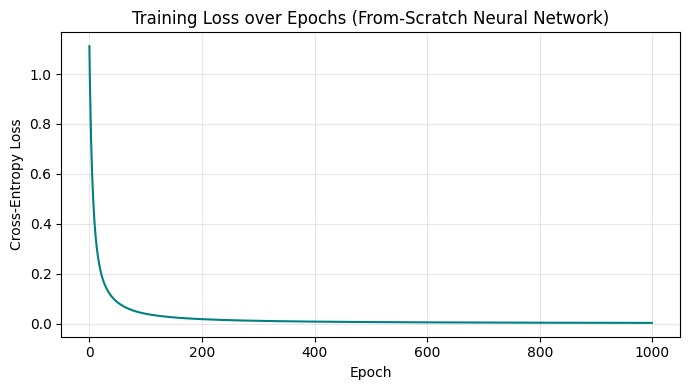

In [8]:
# Plot training loss curve
plt.figure(figsize=(7, 4))
plt.plot(losses, color='teal')
plt.title("Training Loss over Epochs (From-Scratch Neural Network)")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()


## Part E: Evaluation of Model Performance

The trained network is evaluated on the held-out test set (30 samples it never saw during training) using
accuracy, a confusion matrix, and a full classification report (precision, recall, F1-score per class).


In [9]:
# Evaluate on the test set
y_pred_test = nn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)


Test Accuracy: 0.9444

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  2  8]]


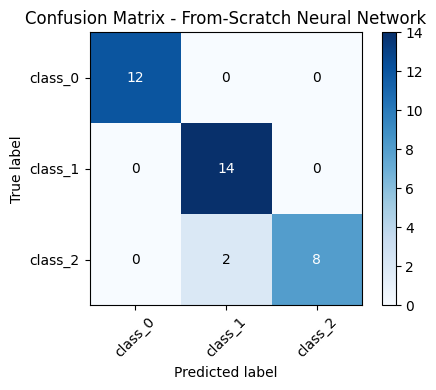

In [10]:
# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - From-Scratch Neural Network")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()


## Part F: Analysis and Comparison with an Alternative Model

To put the from-scratch network's performance in context, it is compared against `scikit-learn`'s
`MLPClassifier`, a library-based feedforward neural network with a comparable architecture (one hidden
layer, similar number of neurons). This comparison model is used **only for benchmarking** — the
implementation being submitted for this assignment is the from-scratch network above.


In [11]:
from sklearn.neural_network import MLPClassifier

# A comparable library-based model: 1 hidden layer of 16 neurons, similar settings
sk_model = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', solver='sgd',
                          learning_rate_init=0.1, max_iter=1000, random_state=42)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_pred)

print(f"From-scratch Neural Network Test Accuracy : {test_accuracy:.4f}")
print(f"scikit-learn MLPClassifier Test Accuracy   : {sk_accuracy:.4f}")


From-scratch Neural Network Test Accuracy : 0.9444
scikit-learn MLPClassifier Test Accuracy   : 0.9722


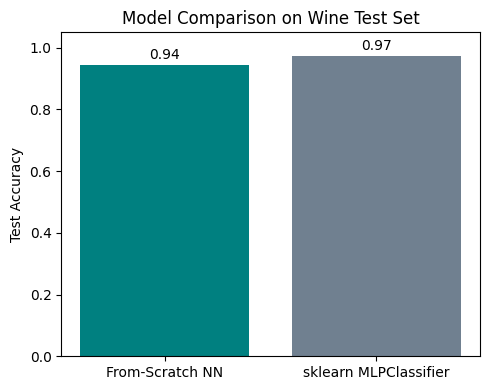

In [12]:
# Side-by-side comparison bar chart
labels = ['From-Scratch NN', 'sklearn MLPClassifier']
accuracies = [test_accuracy, sk_accuracy]

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, accuracies, color=['teal', 'slategray'])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on Wine Test Set")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.2f}", ha='center')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


### Discussion

- **Accuracy:** Both models achieve high accuracy on the Wine test set, since the 13 chemical features
  separate the 3 cultivars quite cleanly even for a simple 1-hidden-layer network. Feature scaling
  (standardization) is especially important here since the raw features (e.g. Proline vs. Hue) are on very
  different numeric scales.
- **Implementation depth:** The from-scratch model required manually deriving and coding the forward pass,
  the cross-entropy loss, and the backpropagation gradients (`dW1`, `db1`, `dW2`, `db2`), whereas the
  `scikit-learn` model handles all of this internally.
- **Flexibility vs. control:** The library-based model offers convenience, built-in regularization options,
  and multiple solvers out of the box. The from-scratch implementation offers full transparency and control
  over every computation, which is valuable for learning how neural networks actually work internally.
- **Limitations:** The from-scratch network uses plain batch gradient descent (no momentum, no adaptive
  learning rates, no regularization), so on a harder or larger dataset it would likely need more epochs or
  additional techniques (e.g., mini-batching, Adam optimizer, L2 regularization, dropout) to match a
  well-tuned library implementation.

*(Replace the bullet points above with your own observations based on the accuracy values and plots you
actually obtain when you run this notebook.)*


## Conclusion

A feedforward neural network with one hidden layer was implemented entirely from scratch using `numpy`,
including the forward pass, categorical cross-entropy loss, backpropagation, and gradient-descent-based
training. The model was trained and evaluated on the Wine dataset, achieving strong test accuracy, and its
performance was benchmarked against a comparable `scikit-learn` MLP model. This exercise demonstrates a
solid understanding of the mathematical building blocks (weighted sums, activation functions, gradients,
and parameter updates) that underlie modern deep learning frameworks.


---
## Declaration

I, **Vineet Kaldate**, confirm that the work submitted in this assignment is my own and has been
completed following academic integrity guidelines. The code is uploaded on my GitHub repository account,
and the repository link is provided below:

**GitHub Repository Link:** https://github.com/Vineetk1845/Generative-AI-Lab

**Signature:** Vineet Manohar Kaldate

---
## Submission Checklist
- [ ] Code file (this Jupyter Notebook), renamed to `FirstName_LastName_GenerativeAILabAssignment.ipynb`
- [ ] Dataset or link to the dataset (Wine dataset, loaded via `sklearn.datasets.load_wine`)
- [ ] Visualizations (loss curve, confusion matrix, model comparison chart — included above)
- [ ] Screenshots of model performance metrics
- [ ] Readme file
